In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [45]:
df = pd.read_csv('titanic_toy.csv')

In [46]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [47]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=2)

In [48]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [49]:
x_train['Age_99'] = x_train['Age'].fillna(99)
x_train['Age_minus'] = x_train['Age'].fillna(-1)

x_train['Fare_999'] = x_train['Fare'].fillna(999)
x_train['Fare_minus'] = x_train['Fare'].fillna(-1)

In [50]:
print('Orignal Age  = ' , x_train['Age'].var())
print('Age_99 = '  , x_train['Age_99'].var())
print('Age_minus = ' ,x_train['Age_minus'].var())

print('Orignal Fare = ' , x_train['Fare'].var())
print('Fare_999 = ' , x_train['Fare_999'].var())
print('Fare_minus = ' ,x_train['Fare_minus'].var())

Orignal Age  =  204.34951339046142
Age_99 =  951.7275570187188
Age_minus =  318.0896202624488
Orignal Fare =  2448.1979137063163
Fare_999 =  47219.202652176304
Fare_minus =  2378.5676784883494


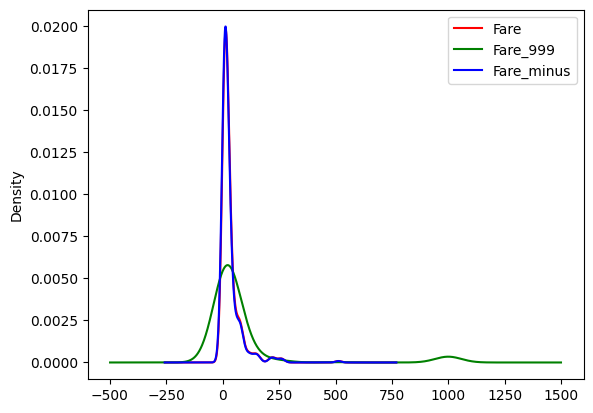

In [51]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Fare'].plot(kind='kde' , color = 'red' , ax=ax)

x_train['Fare_999'].plot(kind='kde' , color='Green' , ax=ax)

x_train['Fare_minus'].plot(kind='kde' , color= 'blue' , ax=ax)

lines , labels = ax.get_legend_handles_labels()
ax.legend(lines , labels , loc='best')

plt.show()

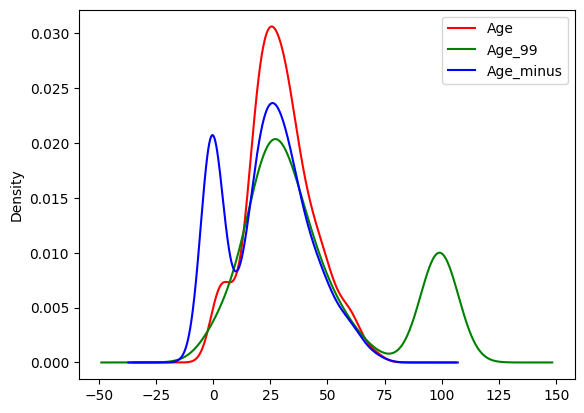

In [52]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Age'].plot(kind='kde' , color = 'red' , ax=ax)

x_train['Age_99'].plot(kind='kde' , color='Green' , ax=ax)

x_train['Age_minus'].plot(kind='kde' , color= 'blue' , ax=ax)

lines , label  = ax.get_legend_handles_labels()

ax.legend(lines , label , loc='best')

In [53]:
x_train.cov()

,Age,Fare,Family,Age_99,Age_minus,Fare_999,Fare_minus
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_minus,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_minus,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [54]:
x_train.corr()

,Age,Fare,Family,Age_99,Age_minus,Fare_999,Fare_minus
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_minus,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_minus,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


In [55]:
x_train

,Age,Fare,Family,Age_99,Age_minus,Fare_999,Fare_minus
30,40.0,27.7208,0,40.0,40.0,27.7208,27.7208
10,4.0,16.7000,2,4.0,4.0,16.7000,16.7000
873,47.0,9.0000,0,47.0,47.0,9.0000,9.0000
182,9.0,31.3875,6,9.0,9.0,31.3875,31.3875
876,20.0,9.8458,0,20.0,20.0,9.8458,9.8458
...,...,...,...,...,...,...,...
534,30.0,8.6625,0,30.0,30.0,8.6625,8.6625
584,NaN,8.7125,0,99.0,-1.0,8.7125,8.7125
493,71.0,49.5042,0,71.0,71.0,49.5042,49.5042
527,NaN,221.7792,0,99.0,-1.0,221.7792,221.7792


# **Using sklearn**

In [56]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=2)

In [57]:
imputer1  = SimpleImputer(strategy='constant' , fill_value=99)
imputer2  = SimpleImputer(strategy='constant' , fill_value=999)

In [58]:
trf11 = ColumnTransformer([
    ('Age_imputer' , imputer1 , ['Age']),
    ('Fare_imputer' , imputer2 , ['Fare'])
],remainder='passthrough')

In [59]:
trf11.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Age_imputer', ...), ('Fare_imputer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and 

In [60]:
trf11.named_transformers_['Age_imputer'].statistics_

array([99], dtype=object)

In [61]:
trf11.named_transformers_['Fare_imputer'].statistics_

array([999], dtype=object)

In [62]:
x_train_trans = trf11.transform(x_train)
x_test_trans = trf11.transform(x_test)

In [63]:
features = trf11.get_feature_names_out()

pd.DataFrame(x_train_trans , columns= features)

,Age_imputer__Age,Fare_imputer__Fare,remainder__Family
0,40.0,27.7208,0.0
1,4.0,16.7000,2.0
2,47.0,9.0000,0.0
3,9.0,31.3875,6.0
4,20.0,9.8458,0.0
...,...,...,...
707,30.0,8.6625,0.0
708,99.0,8.7125,0.0
709,71.0,49.5042,0.0
710,99.0,221.7792,0.0
